# Active Learning with pycse.sklearn Models

This notebook demonstrates **ActiveLearner** with pycse's own UQ-capable models:

- **LinearRegressionUQ** - Linear regression with hat-matrix uncertainty
- **NNBR** - Neural Network + Bayesian Ridge for nonlinear UQ

We'll cover:
1. Uncertainty reduction with `LinearRegressionUQ` + `PredictionVariance`
2. Nonlinear optimization with `NNBR` + `ExpectedImprovement`
3. Composite acquisition functions (weighted combinations)
4. Comparing acquisition functions on a multi-modal problem

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import BayesianRidge

from pycse.sklearn.lr_uq import LinearRegressionUQ
from pycse.sklearn.nnbr import NeuralNetworkBLR
from pycse.sklearn.active_learning import (
    ActiveLearner,
    ExpectedImprovement,
    LCB,
    ModelMin,
    PredictionVariance,
    UCB,
)

plt.style.use("default")
plt.rcParams["figure.dpi"] = 100

print("Imports successful")

Imports successful


## 1. Uncertainty Reduction with LinearRegressionUQ

`LinearRegressionUQ` provides hat-matrix-based standard errors. We use
`PredictionVariance` to iteratively add points where the model is most uncertain,
building a better design of experiments.

This is useful when you want to **efficiently map a response surface** rather
than optimize.

/Users/jkitchin/Dropbox/python/pycse/src/pycse/PYCSE.py:140: RuntimeWarning: divide by zero encountered in scalar divide
  sigma2 = np.sum(errors**2, axis=0) / (n - k)  # RMSE
/Users/jkitchin/Dropbox/python/pycse/src/pycse/PYCSE.py:212: RuntimeWarning: divide by zero encountered in scalar divide
  mse = sse / dof  # Was: sse / n


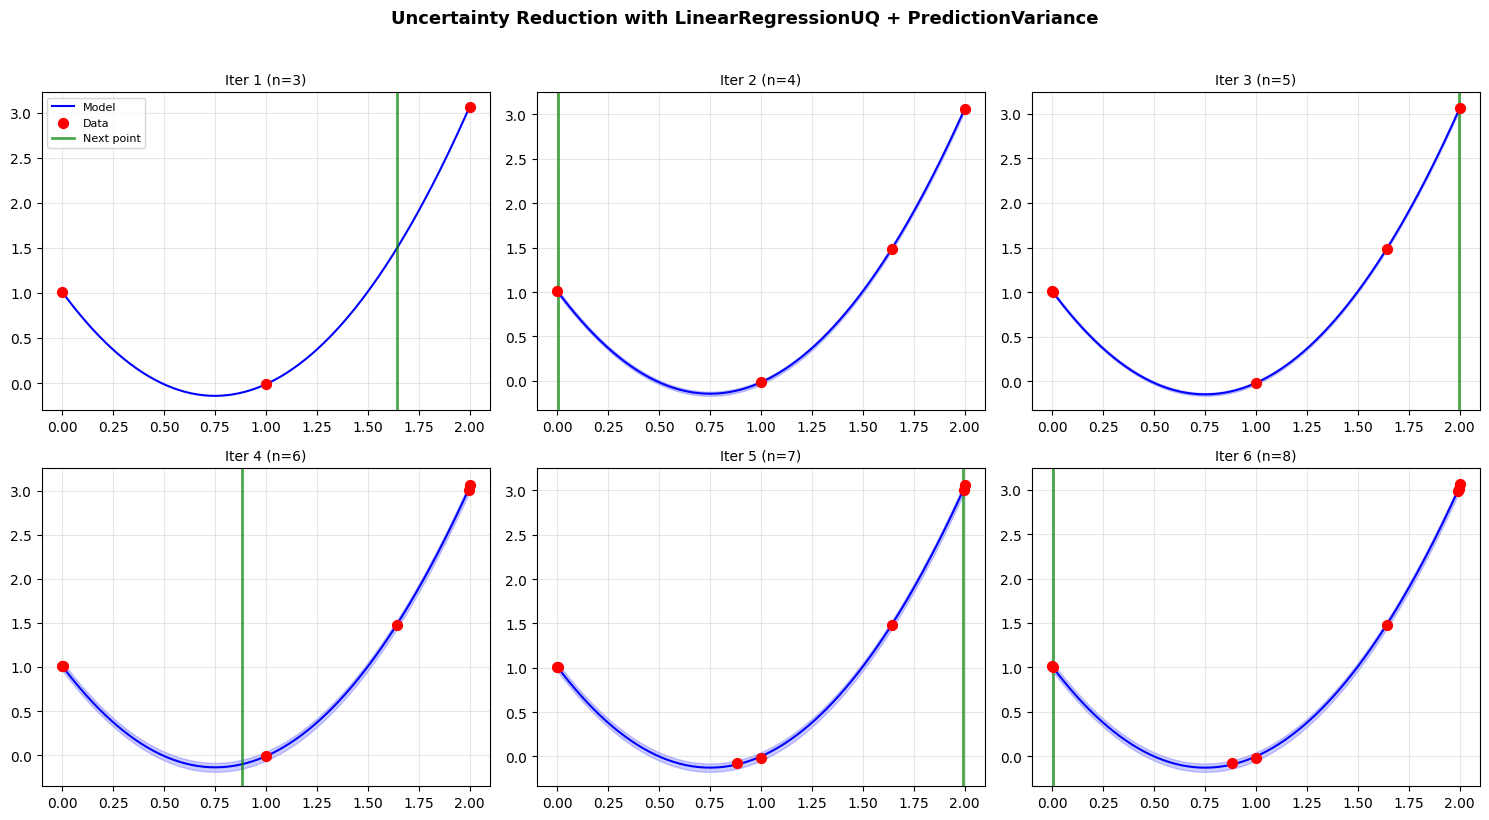

Started with 3 points, now have 9.
The model uncertainty band narrows as we add points where it's most uncertain.


In [2]:
# True function: quadratic in 1D
def quadratic(X):
    x = np.atleast_2d(X)[:, 0]
    return 2.0 * x**2 - 3.0 * x + 1.0 + 0.1 * np.random.default_rng(0).normal(size=len(x))


# LinearRegressionUQ expects a design matrix with polynomial features.
# We'll create a helper that builds [1, x, x^2] features.
def make_features(X):
    x = np.atleast_2d(X)[:, 0]
    return np.column_stack([np.ones_like(x), x, x**2])


class PolyLRUQ:
    """LinearRegressionUQ wrapped with polynomial feature generation."""

    def __init__(self):
        self._model = LinearRegressionUQ()

    def fit(self, X, y):
        self._X_raw = np.atleast_2d(X)
        self._model.fit(make_features(X), y)
        return self

    def predict(self, X, return_std=False):
        return self._model.predict(make_features(X), return_std=return_std)


# Start with just 3 points at the edges
X_init = np.array([[0.0], [1.0], [2.0]])
y_init = quadratic(X_init)

model = PolyLRUQ()
model.fit(X_init, y_init)

learner = ActiveLearner(
    model=model,
    bounds=[(0, 2)],
    acquisition=PredictionVariance(),
    n_candidates=300,
    random_state=42,
)
learner.X_train = X_init.copy()
learner.y_train = y_init.copy()

# Run 6 iterations
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
x_plot = np.linspace(0, 2, 200)[:, None]

for i, ax in enumerate(axes.flat):
    mu, std = model.predict(x_plot, return_std=True)

    ax.fill_between(x_plot.ravel(), mu - 2 * std, mu + 2 * std, alpha=0.2, color="blue")
    ax.plot(x_plot, mu, "b-", lw=1.5, label="Model")
    ax.scatter(learner.X_train, learner.y_train, c="red", s=50, zorder=5, label="Data")

    result = learner.suggest(n_points=1)
    ax.axvline(result.points[0, 0], color="green", ls="-", lw=2, alpha=0.7, label="Next point")

    ax.set_title(f"Iter {i + 1} (n={learner.n_observations})", fontsize=10)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

    y_new = quadratic(result.points)
    learner.update(result.points, y_new)

plt.suptitle(
    "Uncertainty Reduction with LinearRegressionUQ + PredictionVariance",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

print(f"Started with {len(X_init)} points, now have {learner.n_observations}.")
print("The model uncertainty band narrows as we add points where it's most uncertain.")

## 2. Nonlinear Optimization with NNBR

NNBR provides nonlinear predictions with Bayesian uncertainty, making it a
good surrogate for active learning on more complex functions.

Here we use `ExpectedImprovement` to find the minimum of a wavy function.

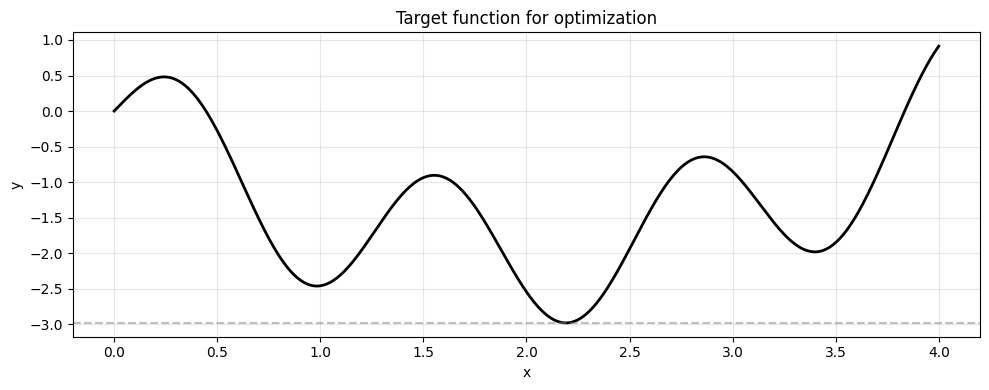

True minimum: y = -2.9808 at x = 2.1884


In [3]:
def wavy(X):
    """1D test function with multiple local minima."""
    x = np.atleast_2d(X)[:, 0]
    return np.sin(5 * x) + 0.5 * x**2 - 2 * x


x_true = np.linspace(0, 4, 500)[:, None]
y_true = wavy(x_true)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_true, y_true, "k-", lw=2)
ax.axhline(y_true.min(), color="gray", ls="--", alpha=0.5)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Target function for optimization")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"True minimum: y = {y_true.min():.4f} at x = {x_true[np.argmin(y_true), 0]:.4f}")

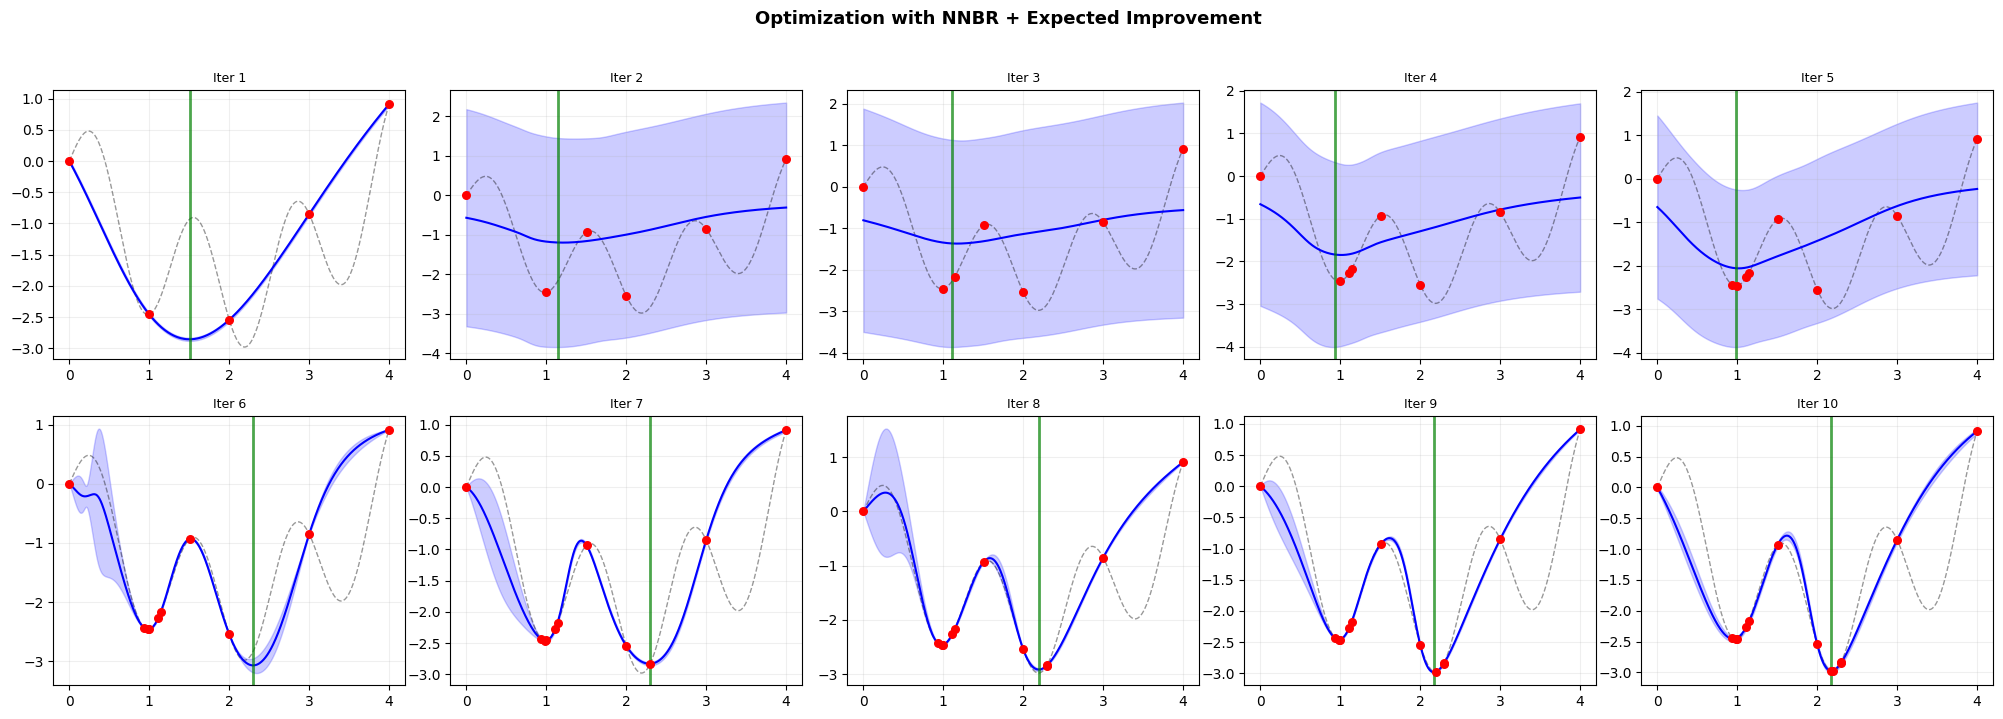

Best y found:  -2.9802  (true min = -2.9808)
Best x found:  2.1988
Total samples: 15


In [4]:
def make_nnbr():
    """Create a fresh NNBR model."""
    nn = MLPRegressor(
        hidden_layer_sizes=(50, 50),
        activation="tanh",
        solver="lbfgs",
        max_iter=1000,
        random_state=42,
    )
    br = BayesianRidge(tol=1e-6, fit_intercept=False, compute_score=True)
    return NeuralNetworkBLR(nn, br)


# Initial data: 5 evenly-spaced points
rng = np.random.RandomState(42)
X_init = np.linspace(0, 4, 5)[:, None]
y_init = wavy(X_init)

nnbr = make_nnbr()
nnbr.fit(X_init, y_init)

learner = ActiveLearner(
    model=nnbr,
    bounds=[(0, 4)],
    acquisition=ExpectedImprovement(minimize=True),
    n_candidates=500,
    random_state=42,
)
learner.X_train = X_init.copy()
learner.y_train = y_init.copy()

# Run 10 iterations
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
best_history = []

for i, ax in enumerate(axes.flat):
    mu, std = nnbr.predict(x_true, return_std=True)
    ax.plot(x_true, y_true, "k--", lw=1, alpha=0.4)
    ax.plot(x_true, mu, "b-", lw=1.5)
    ax.fill_between(x_true.ravel(), mu - 2 * std, mu + 2 * std, alpha=0.2, color="blue")
    ax.scatter(learner.X_train, learner.y_train, c="red", s=30, zorder=5)

    result = learner.suggest(n_points=1)
    ax.axvline(result.points[0, 0], color="green", ls="-", alpha=0.7, lw=2)
    ax.set_title(f"Iter {i + 1}", fontsize=9)
    ax.grid(True, alpha=0.2)

    y_new = wavy(result.points)
    learner.update(result.points, y_new)  # refits NNBR automatically
    best_history.append(learner.best_y)

plt.suptitle(
    "Optimization with NNBR + Expected Improvement",
    fontsize=13,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

print(f"Best y found:  {learner.best_y:.4f}  (true min = {y_true.min():.4f})")
print(f"Best x found:  {learner.best_X[0]:.4f}")
print(f"Total samples: {learner.n_observations}")

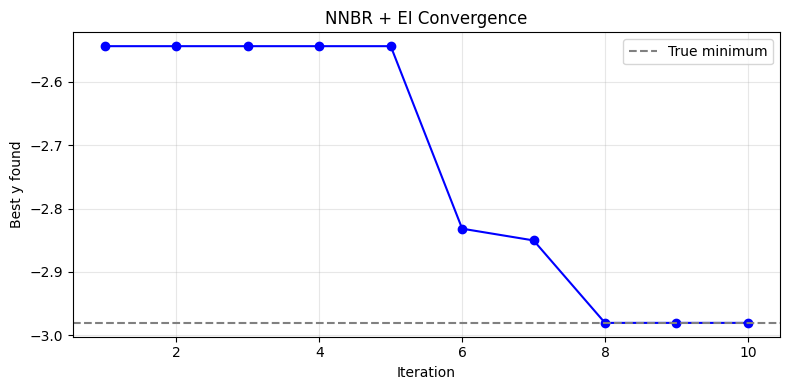

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(best_history) + 1), best_history, "o-", color="blue")
ax.axhline(y_true.min(), color="gray", ls="--", label="True minimum")
ax.set_xlabel("Iteration")
ax.set_ylabel("Best y found")
ax.set_title("NNBR + EI Convergence")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Composite Acquisition Functions

You can combine acquisition functions with `+` and `*` operators.
Each component is min-max normalized before weighting, so different
scales don't matter.

Here we blend exploitation (ModelMin) with exploration (PredictionVariance).

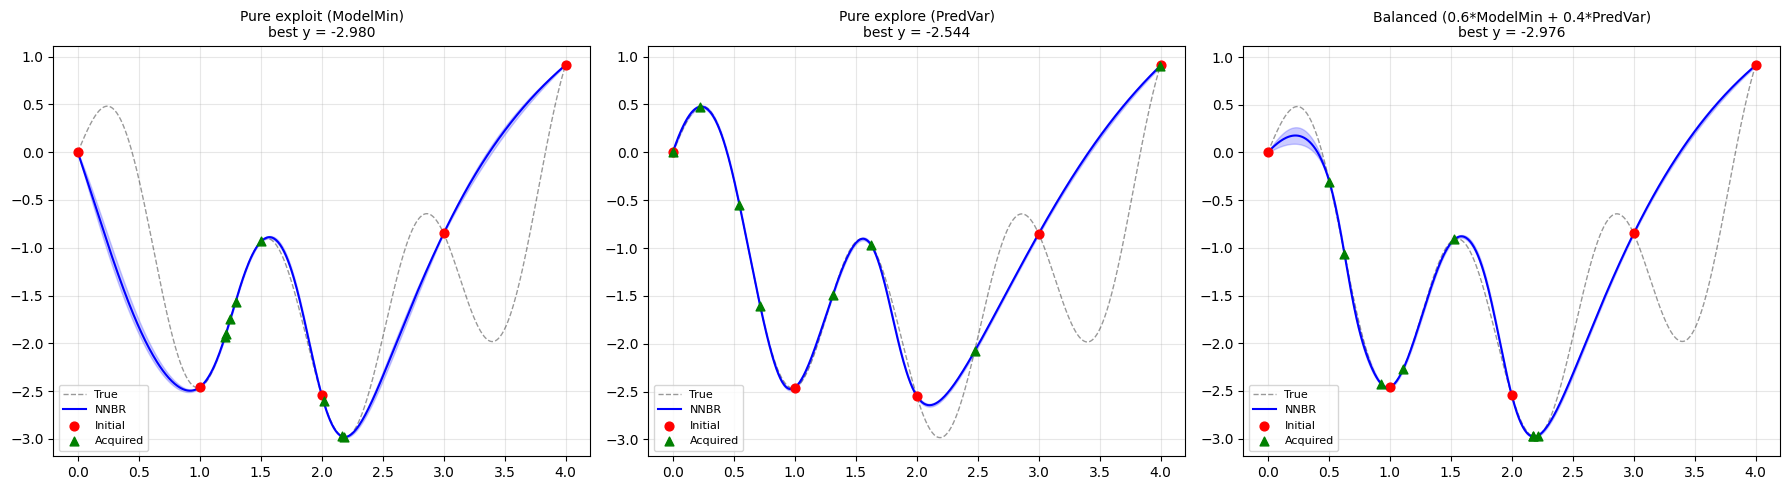

Pure exploit clusters near the predicted minimum.
Pure explore fills in the most uncertain regions.
Balanced does both: finds the minimum while maintaining model quality.


In [6]:
X_init = np.linspace(0, 4, 5)[:, None]
y_init = wavy(X_init)

# Three strategies: pure exploit, pure explore, balanced
strategies = {
    "Pure exploit (ModelMin)": ModelMin(),
    "Pure explore (PredVar)": PredictionVariance(),
    "Balanced (0.6*ModelMin + 0.4*PredVar)": 0.6 * ModelMin() + 0.4 * PredictionVariance(),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, acq) in zip(axes, strategies.items()):
    nnbr = make_nnbr()
    nnbr.fit(X_init, y_init)

    learner = ActiveLearner(
        model=nnbr,
        bounds=[(0, 4)],
        acquisition=acq,
        n_candidates=500,
        random_state=42,
    )
    learner.X_train = X_init.copy()
    learner.y_train = y_init.copy()

    # 8 iterations
    for _ in range(8):
        result = learner.suggest(n_points=1)
        y_new = wavy(result.points)
        learner.update(result.points, y_new)

    mu, std = nnbr.predict(x_true, return_std=True)
    ax.plot(x_true, y_true, "k--", lw=1, alpha=0.4, label="True")
    ax.plot(x_true, mu, "b-", lw=1.5, label="NNBR")
    ax.fill_between(x_true.ravel(), mu - 2 * std, mu + 2 * std, alpha=0.2, color="blue")
    ax.scatter(learner.X_train[:5], learner.y_train[:5], c="red", s=40, zorder=5, label="Initial")
    ax.scatter(
        learner.X_train[5:],
        learner.y_train[5:],
        c="green",
        s=40,
        marker="^",
        zorder=5,
        label="Acquired",
    )
    ax.set_title(f"{name}\nbest y = {learner.best_y:.3f}", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Pure exploit clusters near the predicted minimum.")
print("Pure explore fills in the most uncertain regions.")
print("Balanced does both: finds the minimum while maintaining model quality.")

## 4. Acquisition Function Comparison on a Multi-modal Problem

Let's compare several acquisition functions on the same problem to see
how they balance exploration and exploitation.

/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


/Users/jkitchin/Dropbox/uv/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


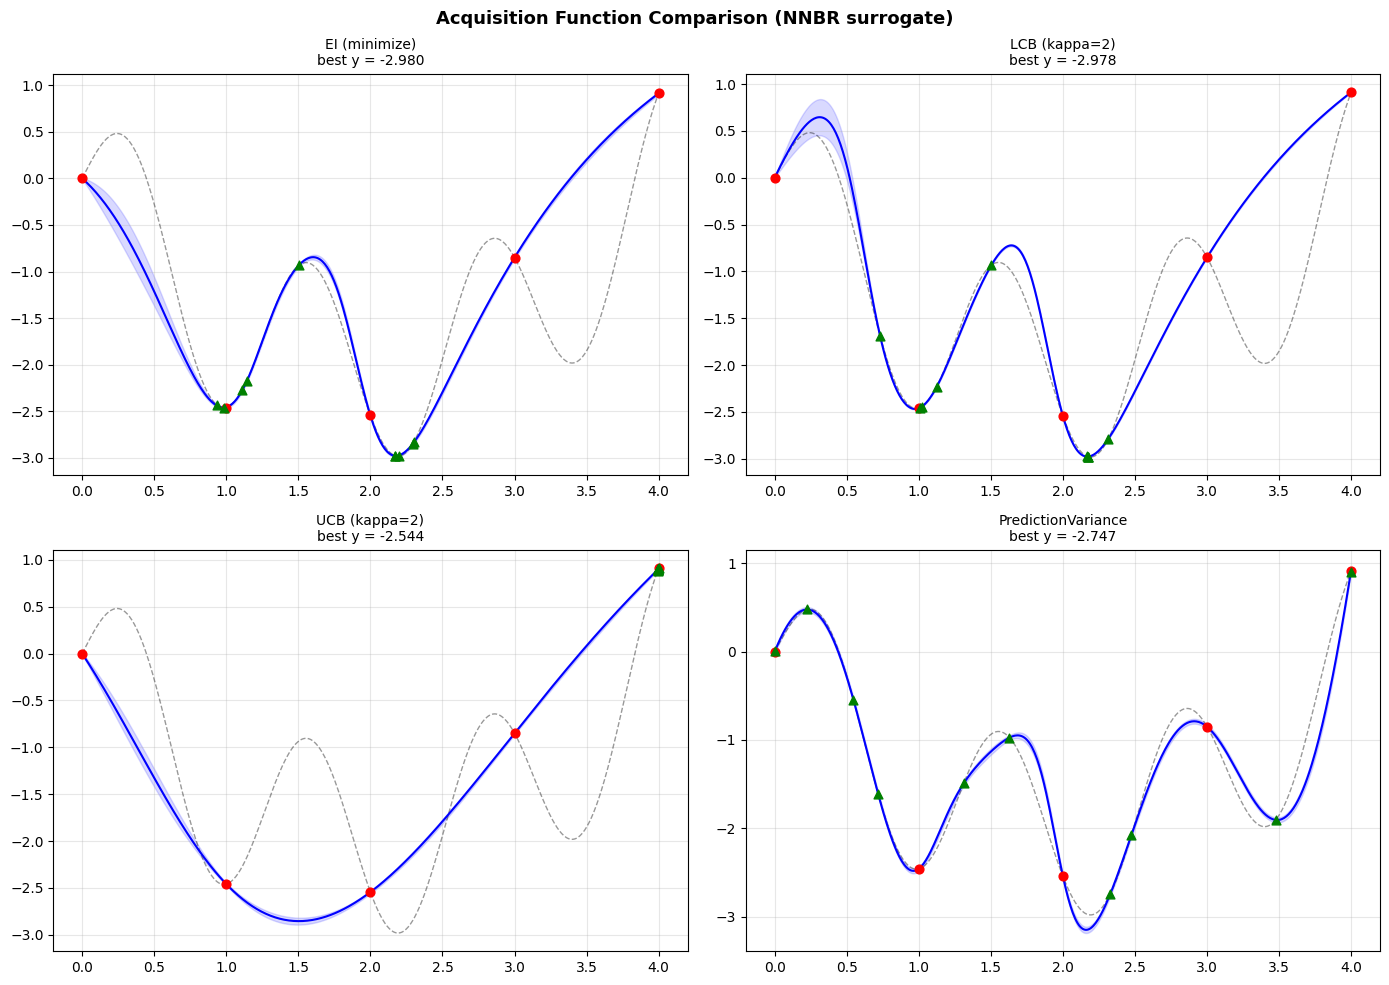

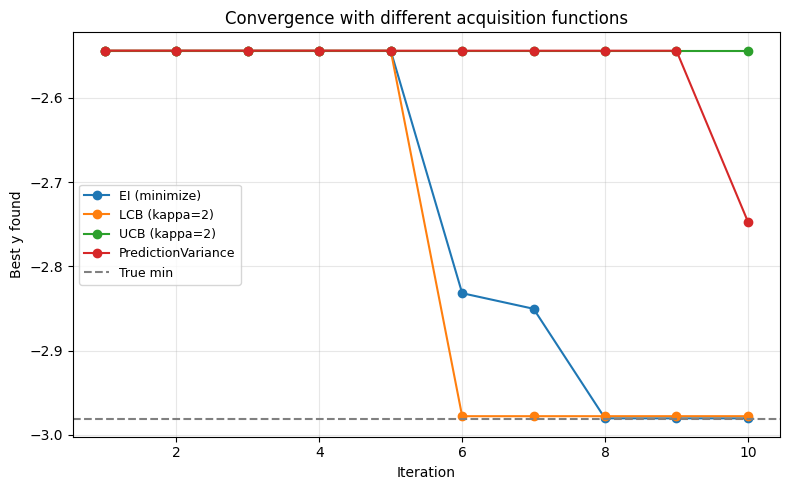

In [7]:
acquisitions = {
    "EI (minimize)": ExpectedImprovement(minimize=True),
    "LCB (kappa=2)": LCB(kappa=2.0),
    "UCB (kappa=2)": UCB(kappa=2.0),
    "PredictionVariance": PredictionVariance(),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
convergence = {}

for ax, (name, acq) in zip(axes.flat, acquisitions.items()):
    nnbr = make_nnbr()
    nnbr.fit(X_init, y_init)

    learner = ActiveLearner(
        model=nnbr,
        bounds=[(0, 4)],
        acquisition=acq,
        n_candidates=500,
        random_state=42,
    )
    learner.X_train = X_init.copy()
    learner.y_train = y_init.copy()

    bests = []
    for _ in range(10):
        result = learner.suggest(n_points=1)
        y_new = wavy(result.points)
        learner.update(result.points, y_new)
        bests.append(learner.best_y)

    convergence[name] = bests

    mu, std = nnbr.predict(x_true, return_std=True)
    ax.plot(x_true, y_true, "k--", lw=1, alpha=0.4)
    ax.plot(x_true, mu, "b-", lw=1.5)
    ax.fill_between(x_true.ravel(), mu - 2 * std, mu + 2 * std, alpha=0.15, color="blue")
    ax.scatter(learner.X_train[:5], learner.y_train[:5], c="red", s=40, zorder=5)
    ax.scatter(
        learner.X_train[5:],
        learner.y_train[5:],
        c="green",
        s=40,
        marker="^",
        zorder=5,
    )
    ax.set_title(f"{name}\nbest y = {learner.best_y:.3f}", fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("Acquisition Function Comparison (NNBR surrogate)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Convergence
fig, ax = plt.subplots(figsize=(8, 5))
for name, bests in convergence.items():
    ax.plot(range(1, len(bests) + 1), bests, "o-", label=name)
ax.axhline(y_true.min(), color="gray", ls="--", label="True min")
ax.set_xlabel("Iteration")
ax.set_ylabel("Best y found")
ax.set_title("Convergence with different acquisition functions")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

- **LinearRegressionUQ** works well for active experimental design when the
  underlying model is polynomial. `PredictionVariance` fills in gaps efficiently.
- **NNBR** handles nonlinear functions and provides Bayesian uncertainty for
  acquisition functions like `ExpectedImprovement`.
- **Composite acquisition** lets you blend strategies:
  `0.6 * ModelMin() + 0.4 * PredictionVariance()` balances exploitation and exploration.
- Any pycse.sklearn model with `predict(X, return_std=True)` works with `ActiveLearner`
  (DPOSE, KfoldNN, NNBR, etc.).